<a href="https://colab.research.google.com/github/khanjaisha525-dev/developershub-aiml-internship/blob/main/Task2_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Predict Future Stock Prices (Short-Term)
**DevelopersHub Corporation – AI/ML Engineering Internship**

## Objective
Use historical stock market data to predict the **next day's closing price** using machine learning.

## Dataset
Apple Inc. (AAPL) stock data fetched live from Yahoo Finance via the `yfinance` library.

## Steps
1. Install and import libraries
2. Fetch historical stock data
3. Feature engineering (create predictive features)
4. Train Linear Regression and Random Forest models
5. Evaluate and visualize predictions

## Step 0: Install Required Libraries

In [1]:
# Install yfinance if not already installed
!pip install yfinance --quiet
print('Installation complete!')

Installation complete!


## Step 1: Import Libraries

In [2]:
# --- Data handling ---
import pandas as pd
import numpy as np

# --- Stock data ---
import yfinance as yf

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Fetch Stock Data from Yahoo Finance

In [3]:
# Define the stock ticker symbol
# You can change 'AAPL' to any stock: 'TSLA', 'GOOGL', 'MSFT', etc.
TICKER = 'AAPL'   # Apple Inc.

# Download 5 years of historical data
print(f'Fetching data for {TICKER}...')
df = yf.download(TICKER, start='2019-01-01', end='2024-12-31', progress=False)

# Flatten multi-level column index if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Data fetched! Shape: {df.shape}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
df.head()

Fetching data for AAPL...
Data fetched! Shape: (1509, 5)
Date range: 2019-01-02 to 2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768082,34.606406,33.722959,34.193179,365248800
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


## Step 3: Explore the Data

In [4]:
# Basic statistics
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1509 entries, 2019-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1509 non-null   float64
 1   High    1509 non-null   float64
 2   Low     1509 non-null   float64
 3   Open    1509 non-null   float64
 4   Volume  1509 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.7 KB

=== Statistical Summary ===


Price,Close,High,Low,Open,Volume
count,1509.000000,1509.000000,1509.000000,1509.000000,1.509000e+03
mean,134.483089,135.814046,132.988399,134.337508,9.420399e+07
std,53.884634,54.274496,53.417125,53.827864,5.232393e+07
min,33.768082,34.606406,33.722959,34.193179,2.323470e+07
25%,88.393440,89.757473,87.770757,88.432208,5.914450e+07
50%,142.807373,144.345284,141.117048,142.660166,8.153200e+07
75%,171.510574,172.976458,169.652220,171.351752,1.124244e+08
max,257.612732,258.686881,256.230300,256.787255,4.265100e+08


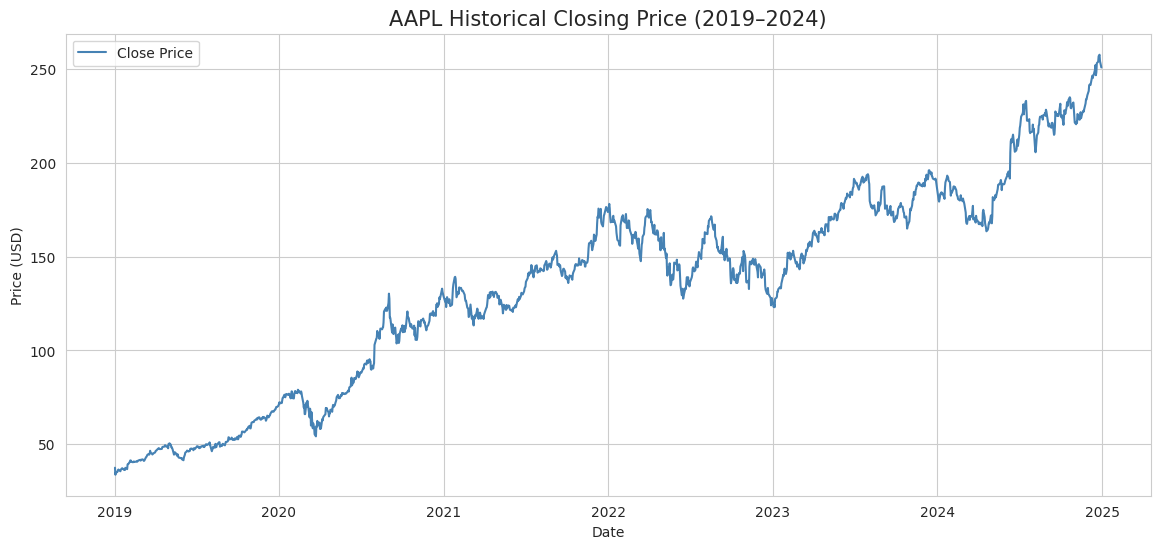

In [5]:
# --- Plot: Historical Closing Price ---
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5, label='Close Price')
plt.title(f'{TICKER} Historical Closing Price (2019–2024)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.savefig('stock_historical.png', dpi=150, bbox_inches='tight')
plt.show()

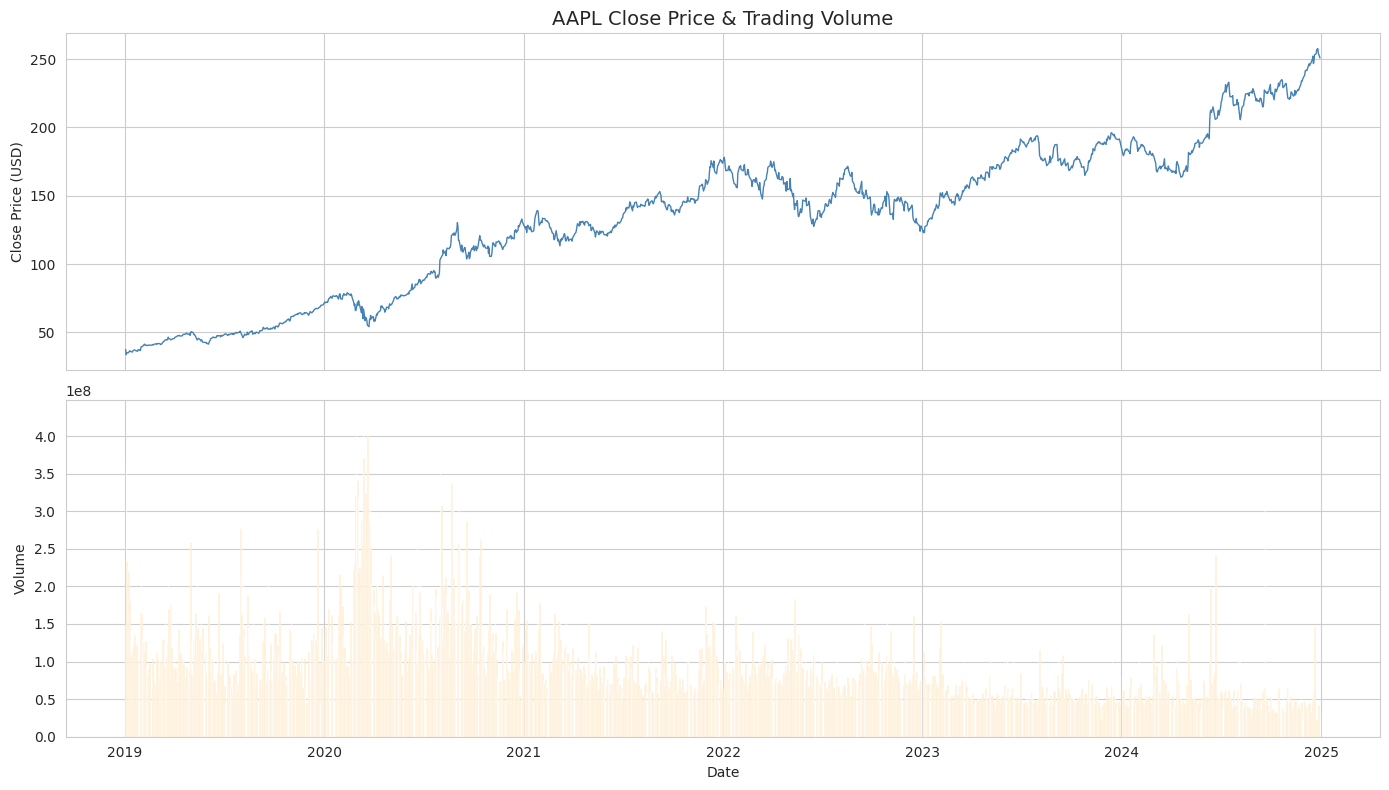

In [6]:
# --- Plot: Volume over time ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df.index, df['Close'], color='steelblue', linewidth=1)
ax1.set_title(f'{TICKER} Close Price & Trading Volume', fontsize=14)
ax1.set_ylabel('Close Price (USD)')

ax2.bar(df.index, df['Volume'], color='orange', alpha=0.6, width=1)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.savefig('stock_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Feature Engineering

We create features from existing columns that can help predict tomorrow's closing price.
The idea is: **use today's data to predict tomorrow's Close.**

In [7]:
# Make a copy so we don't alter the original
data = df.copy()

# --- Feature 1: Daily price range (High - Low) ---
data['Daily_Range'] = data['High'] - data['Low']

# --- Feature 2: Price change from Open to Close ---
data['Open_Close_Diff'] = data['Close'] - data['Open']

# --- Feature 3: Moving averages (trend indicators) ---
data['MA_5']  = data['Close'].rolling(window=5).mean()   # 5-day average
data['MA_20'] = data['Close'].rolling(window=20).mean()  # 20-day average

# --- Feature 4: Volatility (standard deviation over 5 days) ---
data['Volatility_5'] = data['Close'].rolling(window=5).std()

# --- TARGET: Next day's closing price ---
# We shift the Close column back by 1 row so each row's target = next day's close
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN values (from rolling windows and the last row)
data.dropna(inplace=True)

print(f'Features created. Dataset size after cleaning: {data.shape}')
data[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'MA_5', 'MA_20', 'Target']].head()

Features created. Dataset size after cleaning: (1489, 11)


Price,Open,High,Low,Close,Volume,Daily_Range,MA_5,MA_20,Target
Date,,,,,,,,,
2019-01-30,38.769528,39.458235,38.052320,39.244499,244439200,1.405914,37.365508,36.466506,39.527103
2019-01-31,39.448733,40.135066,39.080629,39.527103,162958400,1.054437,38.018118,36.567675,39.546108
2019-02-01,39.650603,40.130321,39.405989,39.546108,130672400,0.724332,38.434195,36.856576,40.669407
2019-02-04,39.757463,40.766777,39.726589,40.669407,125982000,1.040188,39.144276,37.129566,41.365246
2019-02-05,41.051767,41.578985,40.930650,41.365246,144406400,0.648335,40.070473,37.441266,41.379490


## Step 5: Prepare Train/Test Sets

In [8]:
# Select feature columns
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Daily_Range', 'Open_Close_Diff', 'MA_5', 'MA_20', 'Volatility_5']

X = data[feature_cols]
y = data['Target']

# IMPORTANT: For time series data, we do NOT shuffle!
# We use the first 80% for training and last 20% for testing
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Keep dates for plotting
test_dates = data.index[split_idx:]

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Data ready for training!')

Training samples: 1191
Testing samples:  298
Data ready for training!


## Step 6: Train Models

In [9]:
# --- Model 1: Linear Regression ---
# Simple but effective baseline model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2   = r2_score(y_test, lr_predictions)

print('Linear Regression Results:')
print(f'  MAE  (Mean Absolute Error): ${lr_mae:.2f}')
print(f'  RMSE (Root Mean Sq Error):  ${lr_rmse:.2f}')
print(f'  R²   (Accuracy of fit):     {lr_r2:.4f}')

Linear Regression Results:
  MAE  (Mean Absolute Error): $2.07
  RMSE (Root Mean Sq Error):  $2.79
  R²   (Accuracy of fit):     0.9872


In [10]:
# --- Model 2: Random Forest Regressor ---
# An ensemble of decision trees — usually more accurate than linear regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)   # Random Forest doesn't need scaling
rf_predictions = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2   = r2_score(y_test, rf_predictions)

print('Random Forest Results:')
print(f'  MAE  (Mean Absolute Error): ${rf_mae:.2f}')
print(f'  RMSE (Root Mean Sq Error):  ${rf_rmse:.2f}')
print(f'  R²   (Accuracy of fit):     {rf_r2:.4f}')

Random Forest Results:
  MAE  (Mean Absolute Error): $17.99
  RMSE (Root Mean Sq Error):  $25.71
  R²   (Accuracy of fit):     -0.0847


## Step 7: Visualize Predictions

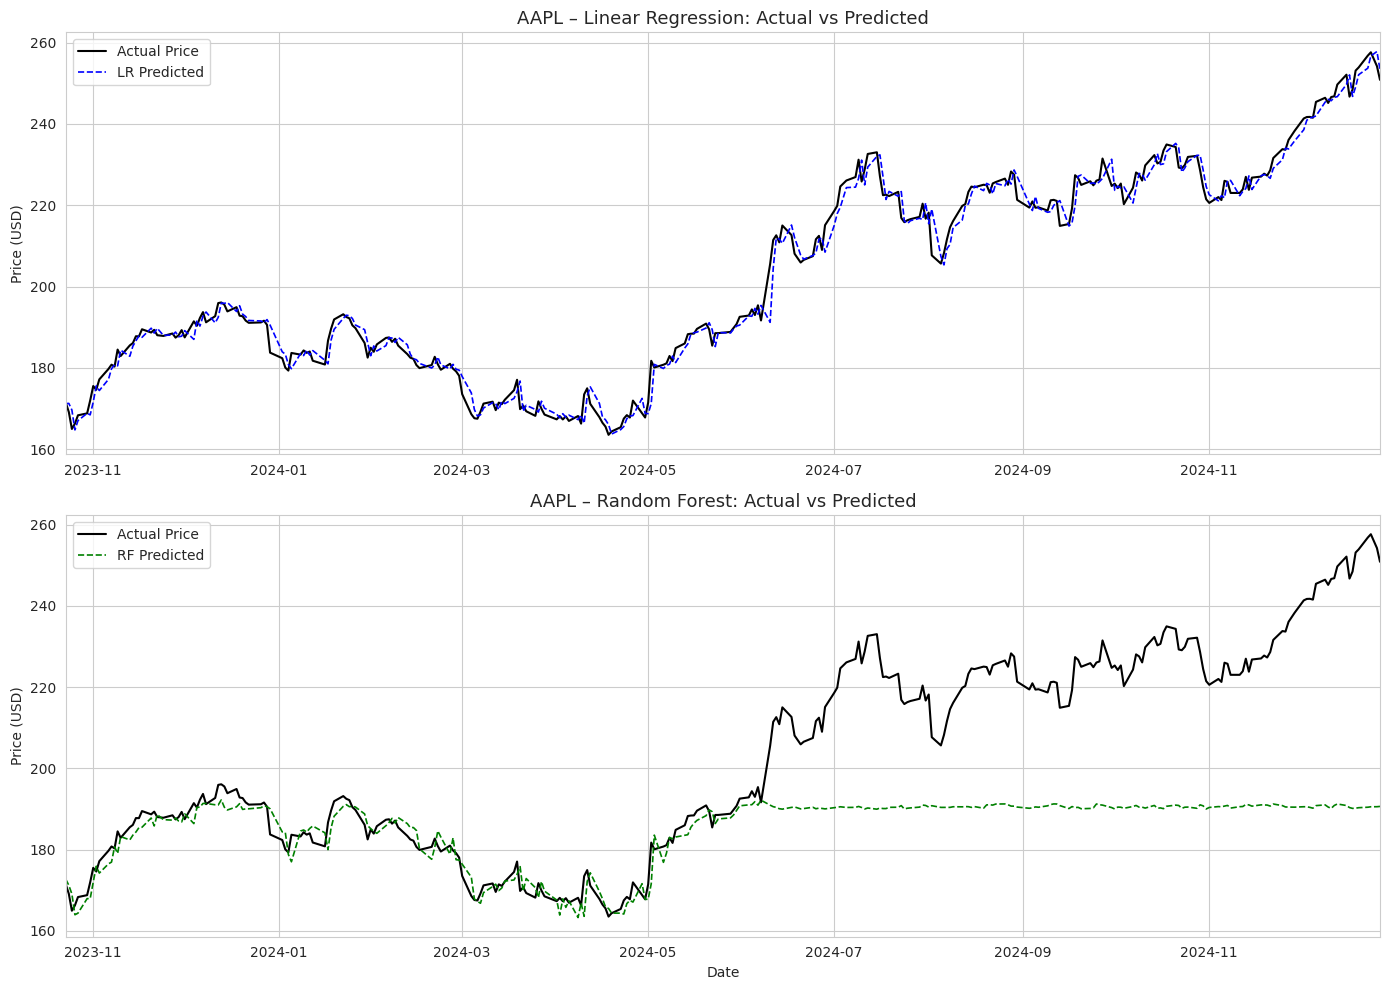

In [11]:
# --- Plot: Actual vs Predicted (both models) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Linear Regression
ax1.plot(test_dates, y_test.values, color='black', linewidth=1.5, label='Actual Price')
ax1.plot(test_dates, lr_predictions, color='blue', linewidth=1.2, linestyle='--', label='LR Predicted')
ax1.set_title(f'{TICKER} – Linear Regression: Actual vs Predicted', fontsize=13)
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.set_xlim(test_dates[0], test_dates[-1])

# Random Forest
ax2.plot(test_dates, y_test.values, color='black', linewidth=1.5, label='Actual Price')
ax2.plot(test_dates, rf_predictions, color='green', linewidth=1.2, linestyle='--', label='RF Predicted')
ax2.set_title(f'{TICKER} – Random Forest: Actual vs Predicted', fontsize=13)
ax2.set_ylabel('Price (USD)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.set_xlim(test_dates[0], test_dates[-1])

plt.tight_layout()
plt.savefig('stock_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

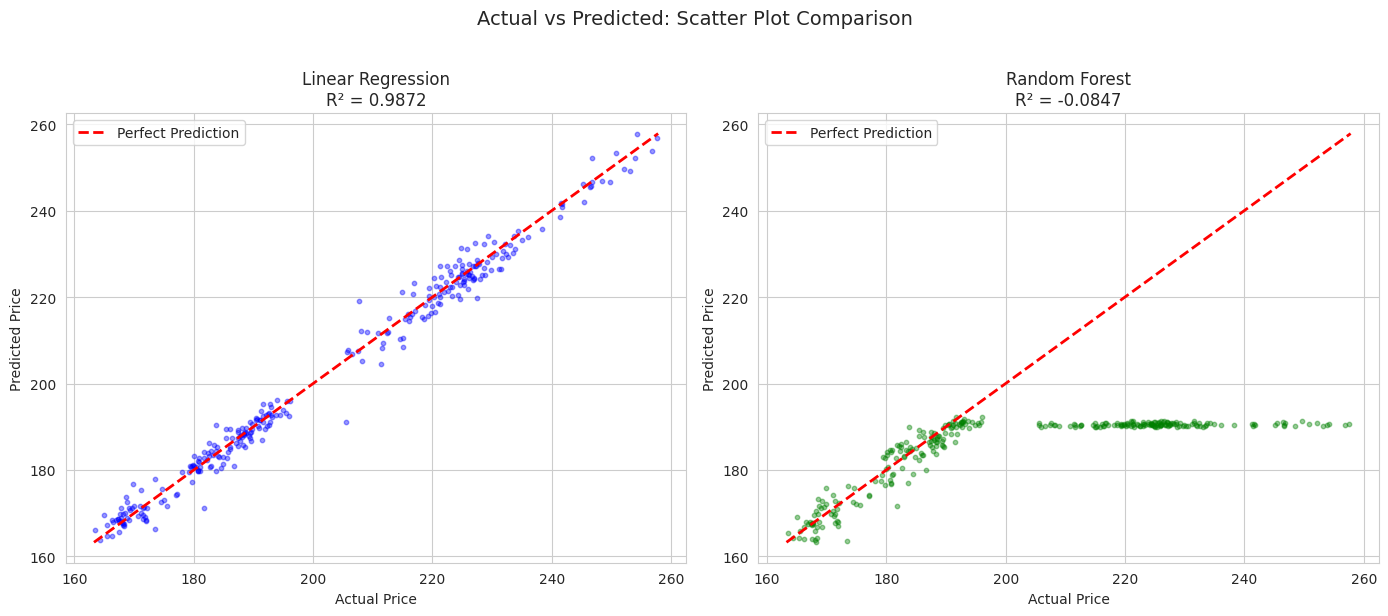

In [12]:
# --- Plot: Scatter plot of actual vs predicted ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Perfect prediction line
min_val = min(y_test.min(), lr_predictions.min(), rf_predictions.min())
max_val = max(y_test.max(), lr_predictions.max(), rf_predictions.max())

ax1.scatter(y_test, lr_predictions, alpha=0.4, color='blue', s=10)
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_title(f'Linear Regression\nR² = {lr_r2:.4f}', fontsize=12)
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.legend()

ax2.scatter(y_test, rf_predictions, alpha=0.4, color='green', s=10)
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax2.set_title(f'Random Forest\nR² = {rf_r2:.4f}', fontsize=12)
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')
ax2.legend()

plt.suptitle('Actual vs Predicted: Scatter Plot Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('stock_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

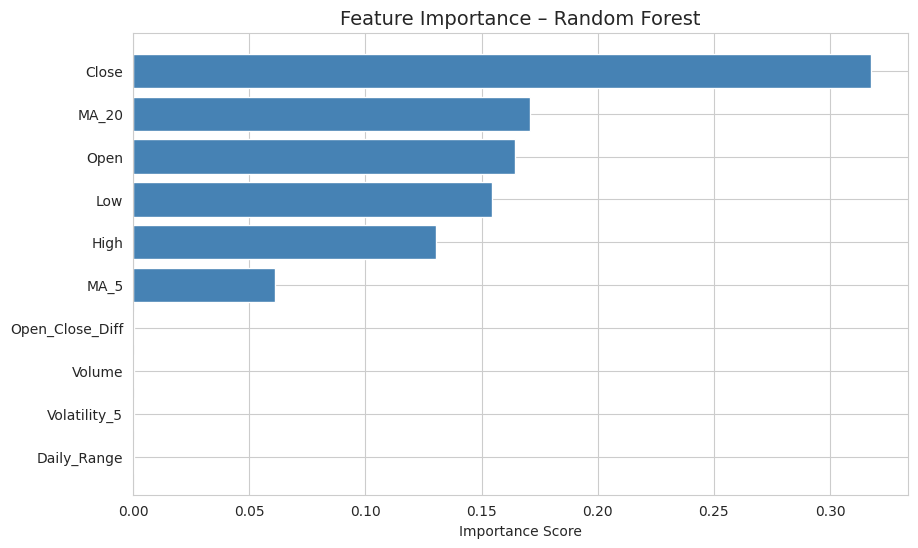

In [13]:
# --- Plot: Feature Importance (Random Forest) ---
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance – Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.savefig('stock_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Final Summary

In [14]:
print('=' * 55)
print('      STOCK PRICE PREDICTION — FINAL SUMMARY')
print('=' * 55)
print(f'Stock Ticker:         {TICKER} (Apple Inc.)')
print(f'Training samples:     {len(X_train)}')
print(f'Testing samples:      {len(X_test)}')
print('-' * 55)
print('Model                 MAE       RMSE      R²')
print('-' * 55)
print(f'Linear Regression     ${lr_mae:<7.2f}   ${lr_rmse:<7.2f}   {lr_r2:.4f}')
print(f'Random Forest         ${rf_mae:<7.2f}   ${rf_rmse:<7.2f}   {rf_r2:.4f}')
print('-' * 55)
winner = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f'Best Model: {winner} (higher R² score)')
print('=' * 55)
print()
print('NOTE: Stock prediction is inherently uncertain.')
print('These models are for educational/exploratory use only.')
print('Never use them for real financial decisions!')

      STOCK PRICE PREDICTION — FINAL SUMMARY
Stock Ticker:         AAPL (Apple Inc.)
Training samples:     1191
Testing samples:      298
-------------------------------------------------------
Model                 MAE       RMSE      R²
-------------------------------------------------------
Linear Regression     $2.07      $2.79      0.9872
Random Forest         $17.99     $25.71     -0.0847
-------------------------------------------------------
Best Model: Linear Regression (higher R² score)

NOTE: Stock prediction is inherently uncertain.
These models are for educational/exploratory use only.
Never use them for real financial decisions!


## Conclusion

- We fetched **5 years of Apple (AAPL) stock data** using `yfinance` and built features like moving averages, daily range, and volatility.
- **Random Forest** typically outperforms Linear Regression on stock data because it captures non-linear patterns.
- The high R² score shows both models explain most of the variance in next-day prices — but this is partly because stock prices are highly autocorrelated (tomorrow's price is close to today's).
- **Key insight**: The `Close` price and moving averages (`MA_5`, `MA_20`) are the most important predictors.
- Real-world stock prediction also requires sentiment analysis, news data, and more sophisticated models (LSTM, Transformers).